In [1]:
import sys
sys.path.append("..")

import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, visualize_connectivity_with_non_local_couplings
from physical_diffusion_fns.network_fns import setup_duffing_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE, create_2d_square_lattice_connectivity, setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn,setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn

jax.config.update("jax_enable_x64", True)

2025-05-27 00:29:55.926706: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.8.93. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Random keys

In [2]:
master_key  = jax.random.PRNGKey(0)          # single seed
sample_target_key, optimization_key, reverse_sde_key = jr.split(master_key, 3)

# Generate samples from a Gaussian mixture - the target distribution

In [3]:
# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [1., 0.5],   # mean of first Gaussian
    [-1., -0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_target = sample_gaussian_mixture(sample_target_key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

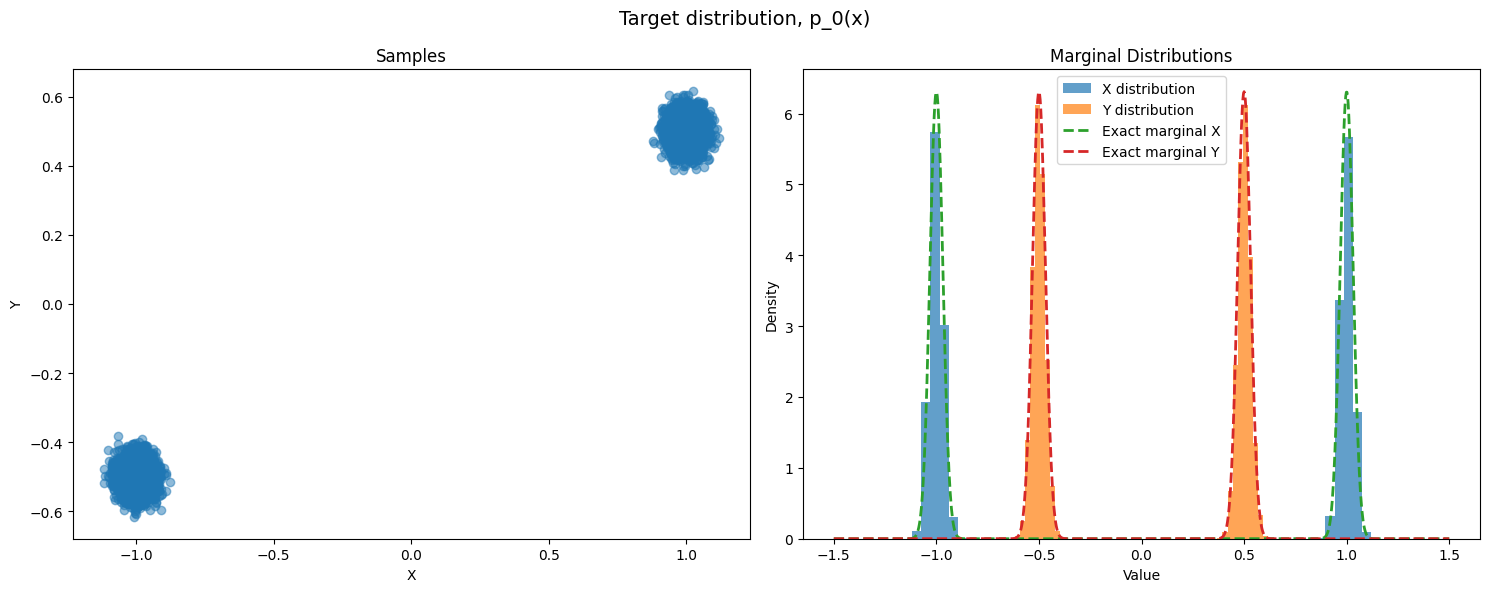

In [4]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_target[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_target[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size and topology and temperature

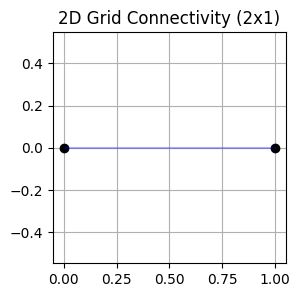

In [5]:
Temp = 0.1
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy

In [6]:
energy_fn_type = "6th_order_duffing_coupling"
if energy_fn_type == "6th_order_duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    k_6_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
    constraint_indices = constraint_indices_k6_self

    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn(connectivity, unflatten)
elif energy_fn_type == "duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_duff_self = jnp.arange(N_osc,2*N_osc)
    constraint_indices_duff_coupling = jnp.arange(2*N_osc+2*num_connections,2*N_osc+3*num_connections)
    constraint_indices = jnp.concatenate([constraint_indices_duff_self, constraint_indices_duff_coupling])
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn(connectivity, unflatten)
elif energy_fn_type == "duffing_optomech_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices = jnp.arange(N_osc,2*N_osc)
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)
else:
    raise ValueError(f"Unknown energy function type: {energy_fn_type}. Choose from '6th_order_duffing_coupling' or 'duffing_coupling'.")

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


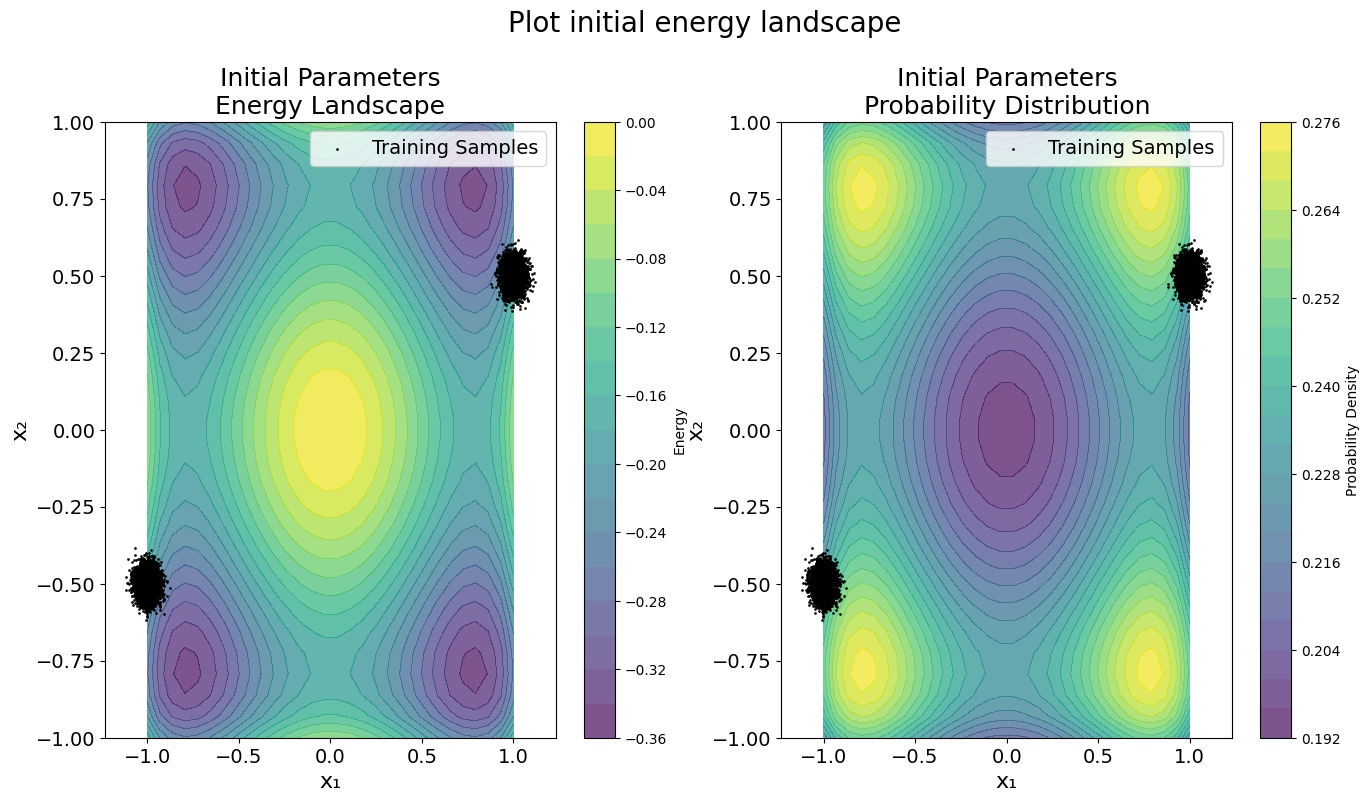

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch, key_CD1: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=Temp, key=key_CD1, num_noise_samples=2000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")


#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 10
t_forward = 1.0
sigma_forward = 1.
exponential_time_pts = False
if exponential_time_pts:
    forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-7), jnp.log(t_forward), n_time_steps))
    forward_time_pts = forward_time_pts.at[0].set(0.)
else:
    forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
# print('forward_time_pts', forward_time_pts)

# Optimization parameters
learning_rate = 0.01
n_epochs = 100000
batch_size = 16*128
window_size=100
tolerance=1e-6
patience=50

In [10]:
problem_type_folder = f"gaussian_mixture/Energy_fn_type_{energy_fn_type}"
optimization_folder = (
           f"exp_time_pts_{exponential_time_pts}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"sigma_forward_{sigma_forward}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}")

# Setup output directories
base_dir = "../out/problems"
output_dir = os.path.join(base_dir, problem_type_folder, f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}", optimization_folder)
plot_folder = os.path.join(output_dir, 'aaa_final_plots')

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plot_folder, exist_ok=True)
print(f"Output directory: {output_dir}")
print(f"Plot directory: {plot_folder}")

save_fig = False

Output directory: ../out/problems/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling/weights_[0.5 0.5]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/exp_time_pts_False_t_forward_1.0_n_timesteps_10_sigma_forward_1.0_lr_0.01_epochs_100000_batch_2048_window_100_tol_1e-06_patience_50
Plot directory: ../out/problems/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling/weights_[0.5 0.5]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/exp_time_pts_False_t_forward_1.0_n_timesteps_10_sigma_forward_1.0_lr_0.01_epochs_100000_batch_2048_window_100_tol_1e-06_patience_50/aaa_final_plots


No existing parameters found, running optimization
t_idx: 0, t_curr: 0.0


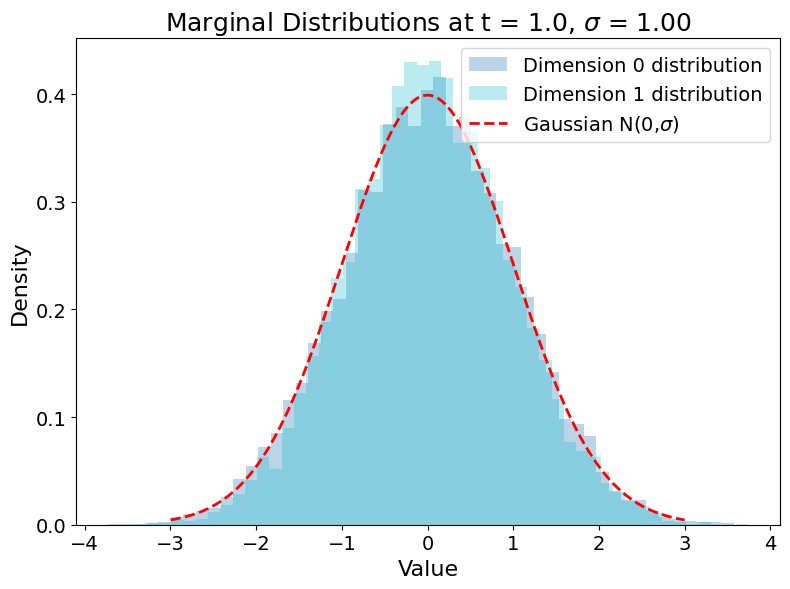

Epoch 0 - Loss: -6.4987
Epoch 100 - Loss: -16.5136
Epoch 200 - Loss: -24.5719
Epoch 300 - Loss: -32.1125
Epoch 400 - Loss: -39.5175
Epoch 500 - Loss: -46.7813
Epoch 600 - Loss: -54.0901
Epoch 700 - Loss: -61.2749
Epoch 800 - Loss: -68.5139
Epoch 900 - Loss: -75.6413
Epoch 1000 - Loss: -82.6928
Epoch 1100 - Loss: -90.0219
Epoch 1200 - Loss: -96.9680
Epoch 1300 - Loss: -104.1388
Epoch 1400 - Loss: -110.7866
Epoch 1500 - Loss: -117.9612
Epoch 1600 - Loss: -124.6514
Epoch 1700 - Loss: -131.7976
Epoch 1800 - Loss: -138.7051
Epoch 1900 - Loss: -145.8066
Epoch 2000 - Loss: -152.3538
Epoch 2100 - Loss: -158.7942
Epoch 2200 - Loss: -165.0504
Epoch 2300 - Loss: -171.9387
Epoch 2400 - Loss: -178.8692
Epoch 2500 - Loss: -184.8854
Epoch 2600 - Loss: -192.2168
Epoch 2700 - Loss: -198.0844
Epoch 2800 - Loss: -205.2141
Epoch 2900 - Loss: -212.4949
Epoch 3000 - Loss: -217.9161
Epoch 3100 - Loss: -223.7242
Epoch 3200 - Loss: -229.1353
Epoch 3300 - Loss: -235.0784
Epoch 3400 - Loss: -241.9506
Epoch 3500 

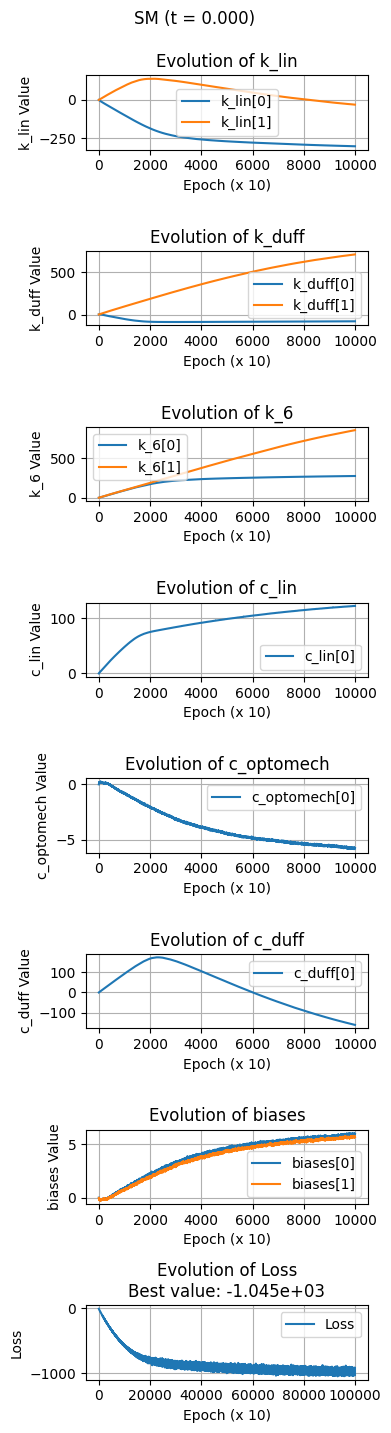

t_idx: 1, t_curr: 0.1111111111111111
Epoch 0 - Loss: 16621.3828
Epoch 100 - Loss: 16367.1593
Epoch 200 - Loss: 13444.9678
Epoch 300 - Loss: 14724.2299
Epoch 400 - Loss: 13554.8818
Epoch 500 - Loss: 17436.9218
Epoch 600 - Loss: 14946.2133
Epoch 700 - Loss: 16137.7447
Epoch 800 - Loss: 13749.6299
Epoch 900 - Loss: 12988.3069
Epoch 1000 - Loss: 14907.6984
Epoch 1100 - Loss: 13622.2742
Epoch 1200 - Loss: 14914.1998
Epoch 1300 - Loss: 13633.8669
Epoch 1400 - Loss: 13325.7402
Epoch 1500 - Loss: 11720.5022
Epoch 1600 - Loss: 13480.4172
Epoch 1700 - Loss: 12826.3605
Epoch 1800 - Loss: 13565.7027
Epoch 1900 - Loss: 12673.6224
Epoch 2000 - Loss: 13568.8158
Epoch 2100 - Loss: 11979.3175
Epoch 2200 - Loss: 12622.5485
Epoch 2300 - Loss: 11750.1871
Epoch 2400 - Loss: 12340.8228
Epoch 2500 - Loss: 12544.0003
Epoch 2600 - Loss: 12343.0737
Epoch 2700 - Loss: 12538.2485
Epoch 2800 - Loss: 12406.8446
Epoch 2900 - Loss: 12788.1825
Epoch 3000 - Loss: 11976.4659
Epoch 3100 - Loss: 12111.8232
Epoch 3200 - Lo

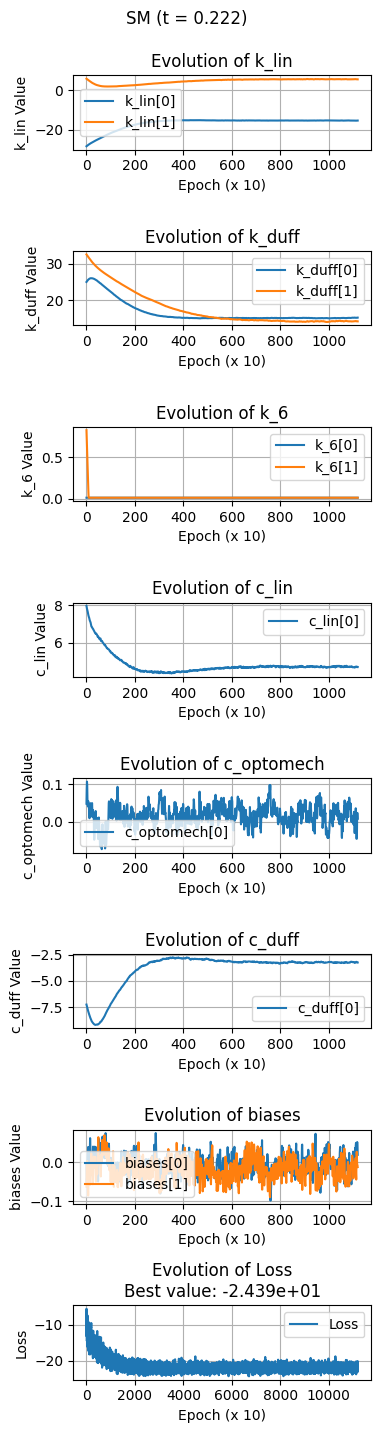

t_idx: 3, t_curr: 0.3333333333333333
Epoch 0 - Loss: -14.1134
Epoch 100 - Loss: -15.9867
Epoch 200 - Loss: -15.4434
Epoch 300 - Loss: -14.9744
Epoch 400 - Loss: -15.0680
Epoch 500 - Loss: -15.5682
Epoch 600 - Loss: -15.1417
Epoch 700 - Loss: -15.7362
Epoch 800 - Loss: -15.3686
Epoch 900 - Loss: -14.5472
Epoch 1000 - Loss: -16.2384
Epoch 1100 - Loss: -16.1929
Epoch 1200 - Loss: -16.2099
Epoch 1300 - Loss: -15.1754
Epoch 1400 - Loss: -14.4177
Epoch 1500 - Loss: -15.4271
Epoch 1600 - Loss: -15.6752
Epoch 1700 - Loss: -15.8101
Epoch 1800 - Loss: -14.8500
Epoch 1900 - Loss: -16.2372
Epoch 2000 - Loss: -15.5235
Epoch 2100 - Loss: -15.0285
Epoch 2200 - Loss: -16.6767
Epoch 2300 - Loss: -15.3808
Epoch 2400 - Loss: -15.3046
Epoch 2500 - Loss: -14.0786
Epoch 2600 - Loss: -14.6297
Epoch 2700 - Loss: -14.2311
Epoch 2800 - Loss: -14.6941
Epoch 2900 - Loss: -15.5732
Epoch 3000 - Loss: -15.1187
Epoch 3100 - Loss: -15.4784
Epoch 3200 - Loss: -15.4368
Epoch 3300 - Loss: -15.3003
Epoch 3400 - Loss: -16.

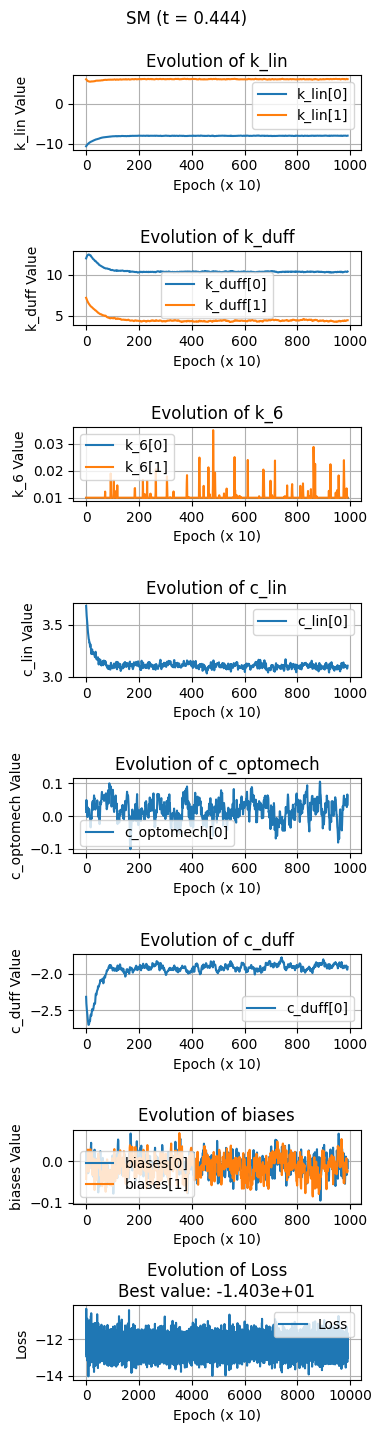

t_idx: 5, t_curr: 0.5555555555555556
Epoch 0 - Loss: -8.8837
Epoch 100 - Loss: -10.7517
Epoch 200 - Loss: -9.7621
Epoch 300 - Loss: -9.3211
Epoch 400 - Loss: -10.7435
Epoch 500 - Loss: -10.8132
Epoch 600 - Loss: -9.9139
Epoch 700 - Loss: -10.4948
Epoch 800 - Loss: -10.8908
Epoch 900 - Loss: -10.9309
Epoch 1000 - Loss: -9.8809
Epoch 1100 - Loss: -10.6664
Epoch 1200 - Loss: -11.2565
Epoch 1300 - Loss: -10.0236
Epoch 1400 - Loss: -10.4666
Epoch 1500 - Loss: -10.8911
Epoch 1600 - Loss: -10.5949
Epoch 1700 - Loss: -10.7008
Epoch 1800 - Loss: -10.6891
Epoch 1900 - Loss: -10.2140
Epoch 2000 - Loss: -10.6532
Epoch 2100 - Loss: -10.0639
Epoch 2200 - Loss: -10.9807
Epoch 2300 - Loss: -10.8720
Epoch 2400 - Loss: -10.6249
Epoch 2500 - Loss: -10.6443
Epoch 2600 - Loss: -10.5441
Epoch 2700 - Loss: -10.4695
Epoch 2800 - Loss: -10.8733
Epoch 2900 - Loss: -10.4448
Epoch 3000 - Loss: -10.8727
Epoch 3100 - Loss: -10.7132
Epoch 3200 - Loss: -10.9511
Epoch 3300 - Loss: -10.2704
Epoch 3400 - Loss: -10.7308


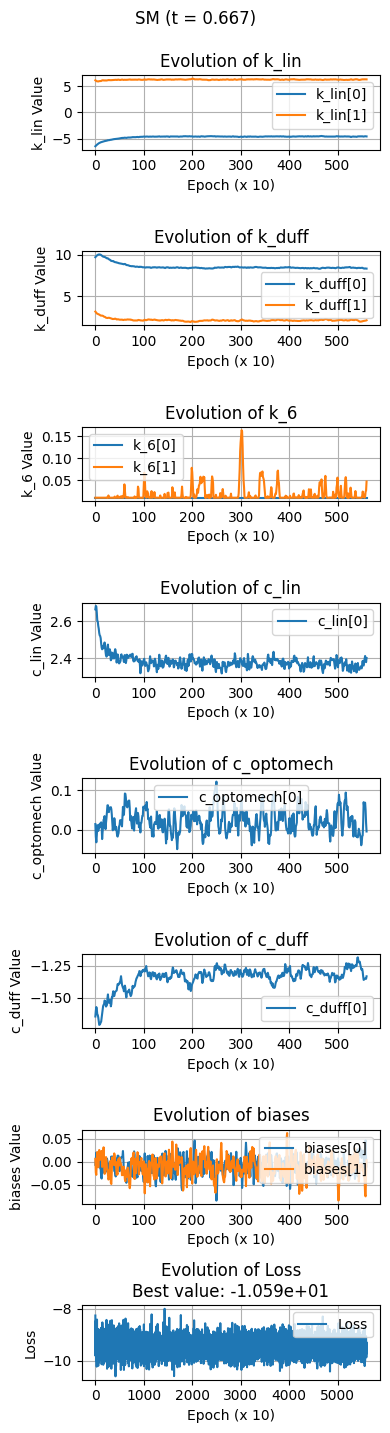

t_idx: 7, t_curr: 0.7777777777777777
Epoch 0 - Loss: -8.8119
Epoch 100 - Loss: -8.6448
Epoch 200 - Loss: -8.8636
Epoch 300 - Loss: -9.1319
Epoch 400 - Loss: -8.8444
Epoch 500 - Loss: -8.6598
Epoch 600 - Loss: -9.1663
Epoch 700 - Loss: -8.8270
Epoch 800 - Loss: -8.7830
Epoch 900 - Loss: -8.5862
Epoch 1000 - Loss: -9.0235
Epoch 1100 - Loss: -8.8937
Epoch 1200 - Loss: -8.5977
Epoch 1300 - Loss: -8.8011
Epoch 1400 - Loss: -8.7337
Epoch 1500 - Loss: -8.8811
Epoch 1600 - Loss: -9.1954
Epoch 1700 - Loss: -8.1948
Epoch 1800 - Loss: -9.1389
Epoch 1900 - Loss: -9.1332
Epoch 2000 - Loss: -8.6309
Epoch 2100 - Loss: -8.8767
Epoch 2200 - Loss: -8.8147
Epoch 2300 - Loss: -8.8912
Epoch 2400 - Loss: -8.4389
Epoch 2500 - Loss: -8.3360
Epoch 2600 - Loss: -9.0130
Epoch 2700 - Loss: -8.4586
Epoch 2800 - Loss: -8.6307
Epoch 2900 - Loss: -8.9674
Epoch 3000 - Loss: -8.5569
Epoch 3100 - Loss: -8.4053
Epoch 3200 - Loss: -8.9273
Epoch 3300 - Loss: -8.9325
Epoch 3400 - Loss: -8.7150
Epoch 3500 - Loss: -9.0344
Epo

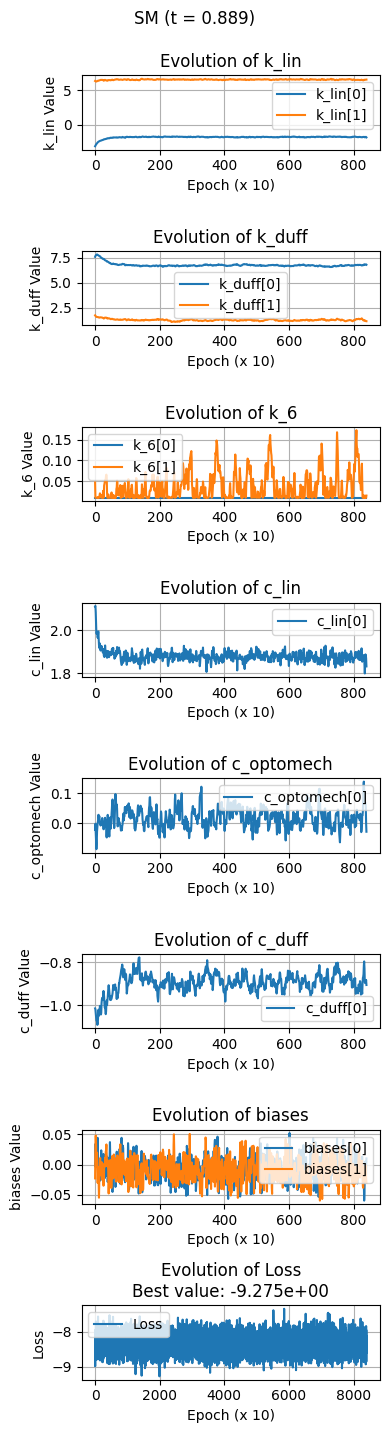

t_idx: 9, t_curr: 1.0
Epoch 0 - Loss: -8.0163
Epoch 100 - Loss: -8.1176
Epoch 200 - Loss: -7.8366
Epoch 300 - Loss: -8.2542
Epoch 400 - Loss: -8.0917
Epoch 500 - Loss: -8.1155
Epoch 600 - Loss: -8.2640
Epoch 700 - Loss: -7.9929
Epoch 800 - Loss: -7.8989
Epoch 900 - Loss: -8.3526
Epoch 1000 - Loss: -8.0529
Epoch 1100 - Loss: -8.0067
Epoch 1200 - Loss: -7.8722
Epoch 1300 - Loss: -8.5657
Epoch 1400 - Loss: -8.3247
Epoch 1500 - Loss: -8.2699
Epoch 1600 - Loss: -8.1633
Epoch 1700 - Loss: -8.6662
Epoch 1800 - Loss: -8.1595
Epoch 1900 - Loss: -7.8697
Epoch 2000 - Loss: -8.2784
Epoch 2100 - Loss: -7.8712
Epoch 2200 - Loss: -8.3509
Epoch 2300 - Loss: -7.9625
Epoch 2400 - Loss: -8.5708
Epoch 2500 - Loss: -8.1216
Epoch 2600 - Loss: -7.7259
Epoch 2700 - Loss: -8.1397
Epoch 2800 - Loss: -8.0464
Epoch 2900 - Loss: -8.5100
Epoch 3000 - Loss: -8.0972
Epoch 3100 - Loss: -8.2937
Epoch 3200 - Loss: -8.2547
Epoch 3300 - Loss: -7.8300
Epoch 3400 - Loss: -8.1715
Epoch 3500 - Loss: -8.1268
Epoch 3600 - Loss:

In [11]:
params_history_path = f"{output_dir}/params_history.npy"
if os.path.exists(params_history_path):
    # Load existing parameters
    print('Loading existing parameters from', params_history_path)
    params_history_all_t = jnp.load(params_history_path)
else:
    print('No existing parameters found, running optimization')    

    # Setup optimization parameters
    mask = jnp.ones(params_flattened_initial.shape[0])

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 2     # Plot every nth step

    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"t_idx: {t_idx}, t_curr: {t_curr}")
        optimization_key, optimization_subkey = jr.split(optimization_key)
        
        if t_idx == 0:
            samples_0 = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_target, key=optimization_key)
            plot_forward_marginals(samples_0, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=save_fig, fontsize=16, plot_show=True)
        
        sampler = lambda key: sample_forward_process(
                t_curr, n_samples = batch_size, D=Temp, sigma_final=sigma_forward, samples0=samples_target, key=key, beta= 1
            )
        
        # Perform optimization starting from previous best parameters
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            sampler=sampler,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=optimization_subkey,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience,
            constraint_indices=constraint_indices
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=save_fig,
                    path=output_dir,
                    param_names=params_names,
                    plot_show=True
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)

    print('Optimization complete; saved parameters to', output_dir)

### Smoothen and interpolate parameter evolution

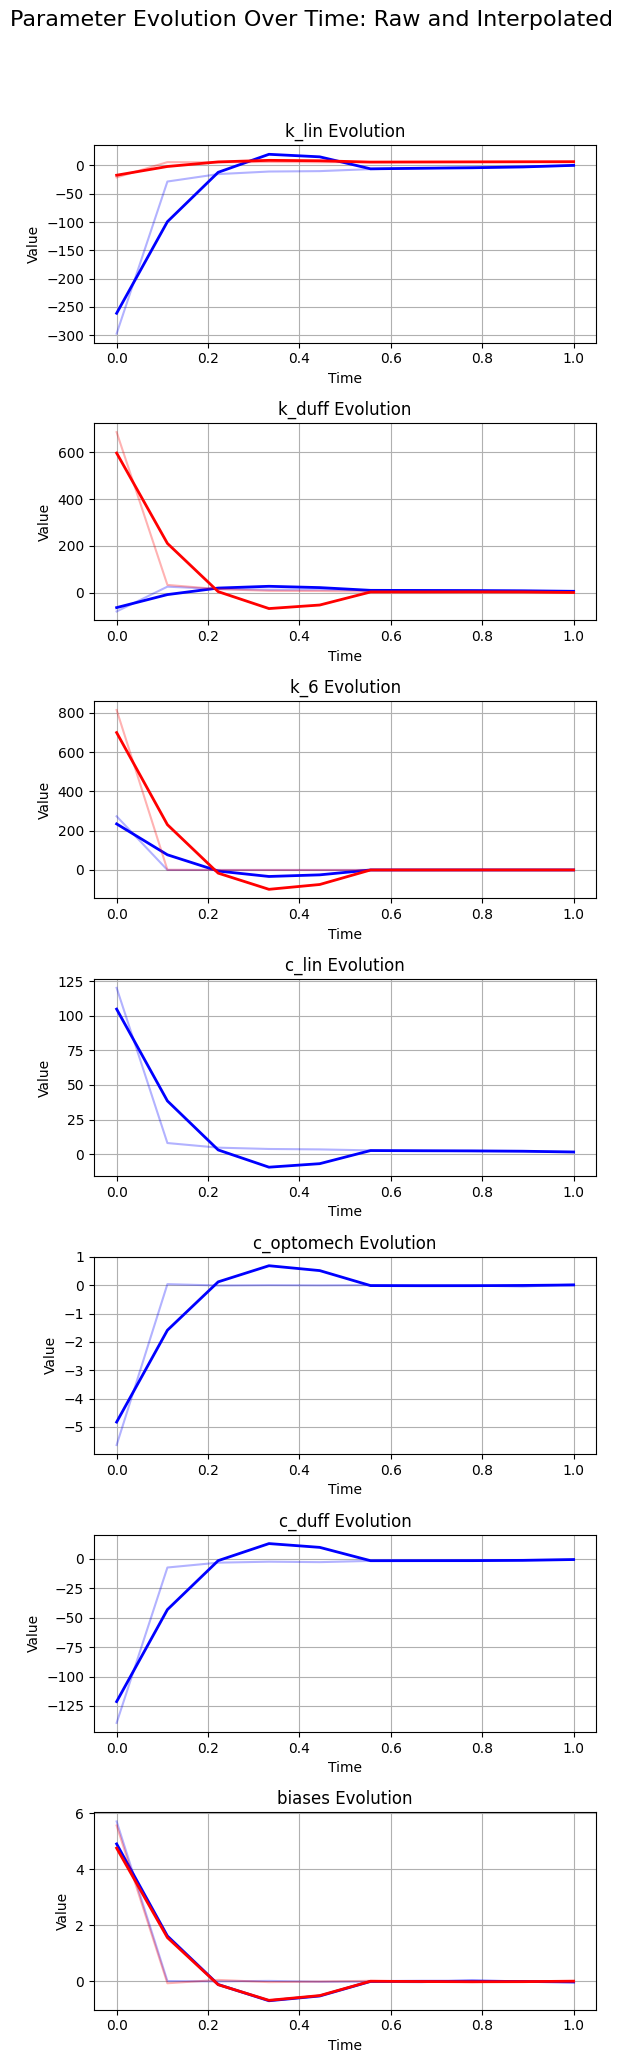

In [12]:
use_smoothed_params = False
smoothed_params = smooth_parameters(params_history_all_t, window_lengths=[10] * params_history_all_t.shape[1], poly_orders=[3] * params_history_all_t.shape[1])

# Get interpolator functions
params_interpolator_smoothed = interpolate_parameters(smoothed_params, forward_time_pts)
params_interpolator_non_smoothed = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0], forward_time_pts[-1], 200)
interpolated_params_smoothed = params_interpolator_smoothed(time_eval)
interpolated_params_non_smoothed = params_interpolator_non_smoothed(time_eval)

plot_parameter_as_fn_of_time(params_names, forward_time_pts, forward_time_pts, params_history_all_t, params_interpolator_smoothed, unflatten, N_osc, save_fig=True, path=plot_folder, log_scale=False,plot_show=True)

if use_smoothed_params:
    params_interpolator = params_interpolator_smoothed
else:
    params_interpolator = params_interpolator_non_smoothed

### Run reverse SDE:

In [18]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:N_osc].set(1.)
if Temp == 0.0:
    params_interpolator_reverse_plus_linear = lambda t: params_interpolator(t_forward - t) - 1 / sigma_forward**2 * forward_params
else:
    params_interpolator_reverse_plus_linear = lambda t: Temp*2*params_interpolator(t_forward - t) - 1 / sigma_forward**2 * forward_params


# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True, Temp=Temp)

t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001
atol = 1e-3
rtol = 1e-5

n_trajectories = 10000

# Generate multiple initial states
reverse_sde_key, subkey_initial = jr.split(reverse_sde_key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=Temp, samples0=samples_target, key=subkey_initial)

# Generate a key for each initial condition
keys_brownian = jr.split(reverse_sde_key, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn,
        diffusion_fn,
        init_state,
        key_b,
        t0,
        t1,
        ts.shape[0],
        dt0,
        rtol=rtol,
        atol=atol
    ),
    in_axes=(0, 0)
)

# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys
final_states = all_trajectories[:, -1, :]

100.00%|##########| [01:50<00:00,  1.11s/%]


### Run equillibirum SDE

In [19]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 0.2
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])

reverse_sde_key, subkey_direct = jr.split(reverse_sde_key)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,subkey_direct, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


100.00%|##########| [02:10<00:00,  1.31s/%]


## Plot samples

Solution from reverse process probability distribution total (should be ≈ 1): 1.000000


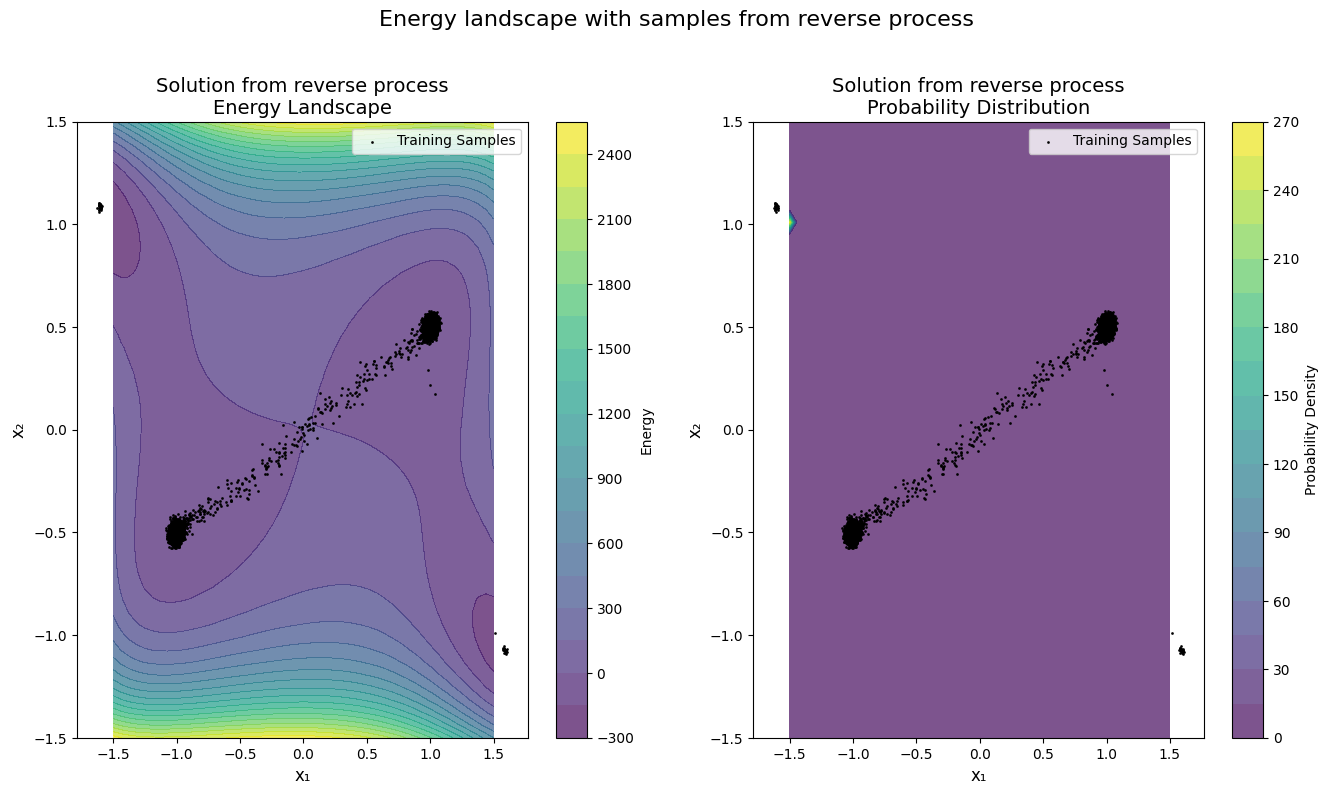

In [20]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

Solution from direct integration probability distribution total (should be ≈ 1): 1.000000


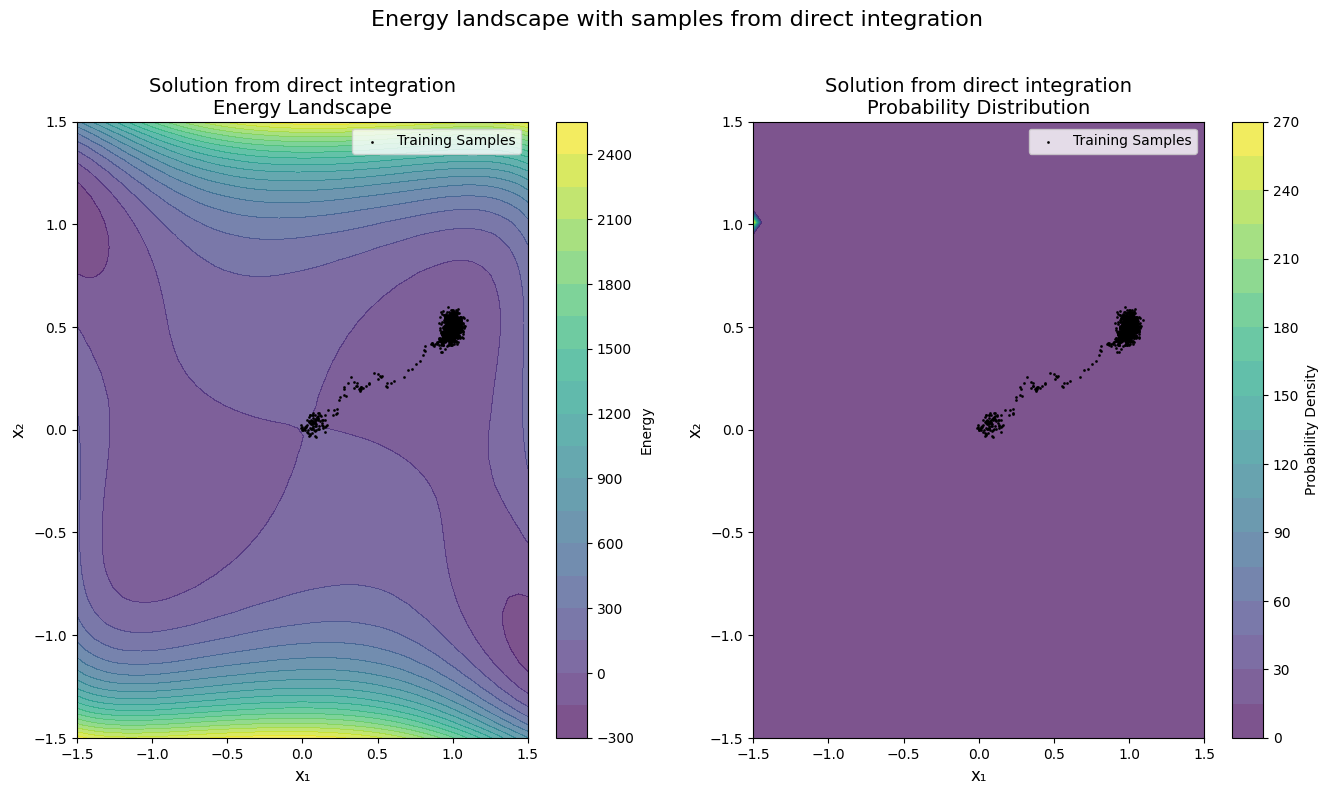

In [21]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

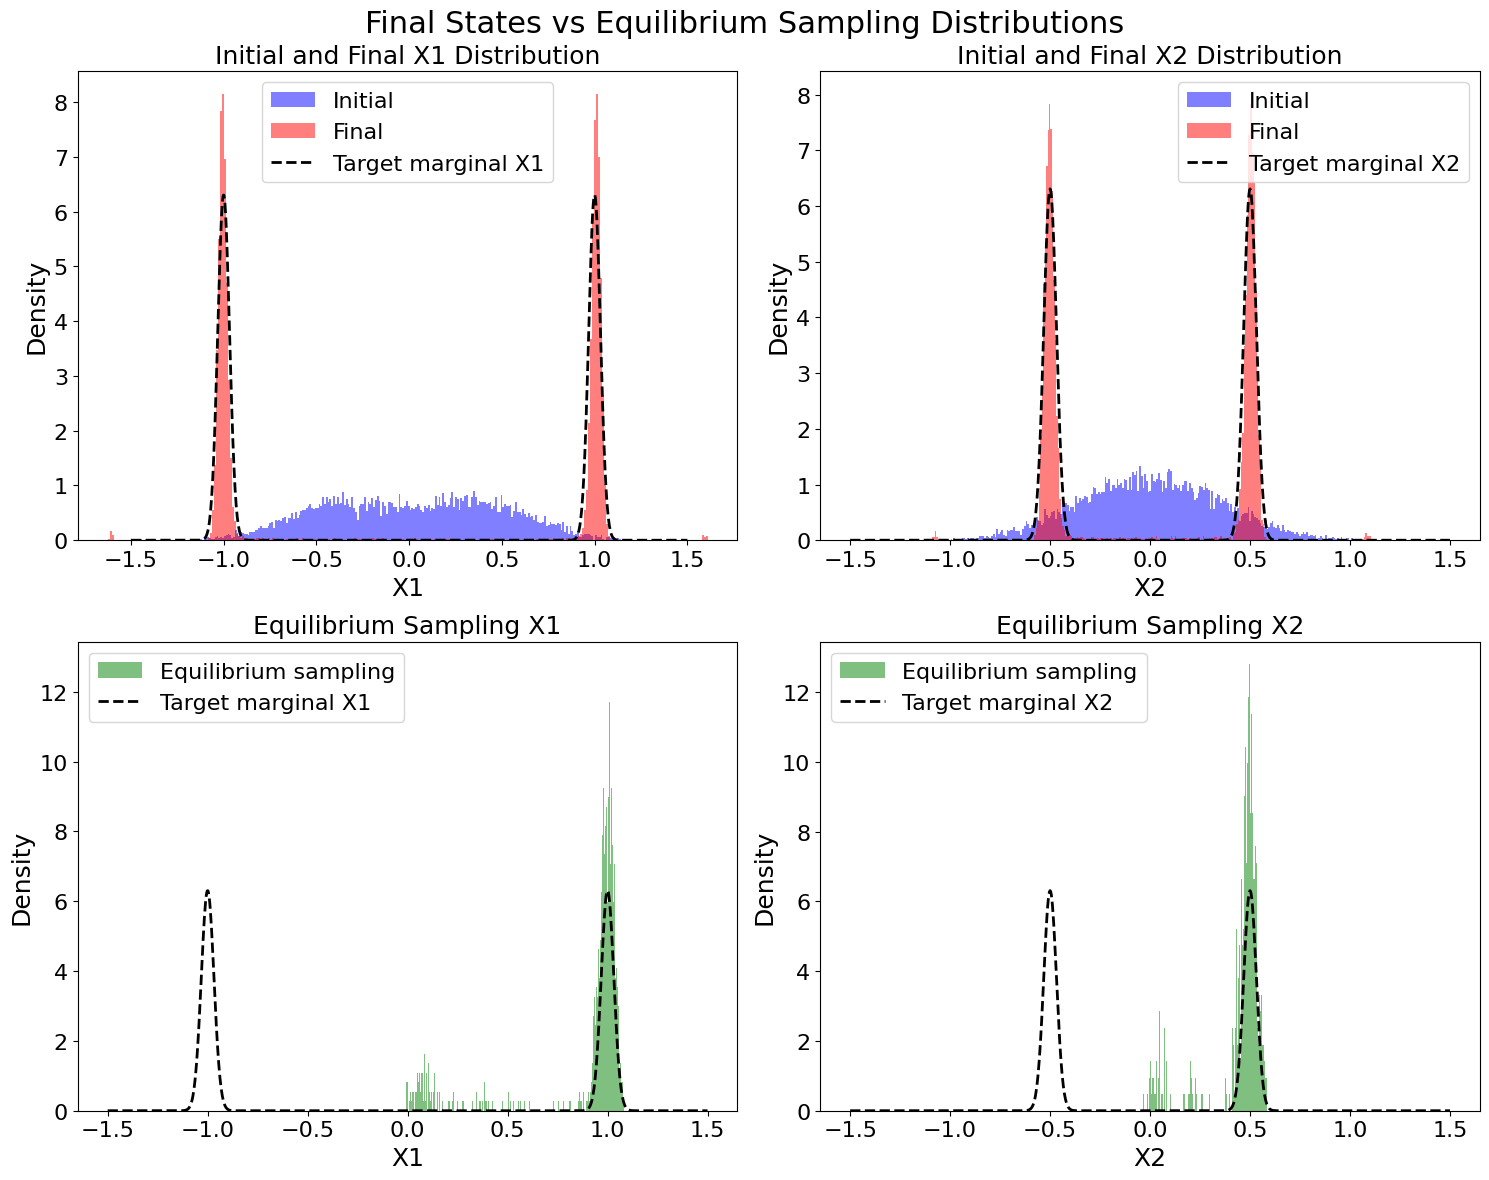

In [22]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=300, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=300, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=300, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=300, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=300, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=300, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()